In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
df = pd.read_csv("House Price Prediction Dataset.csv")

In [ ]:
X = df[["Area", "Bedrooms", "Bathrooms"]]
y = df["Price"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)


KNeighborsRegressor()

In [ ]:
y_pred = knn.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 260354.96850000002
MSE: 98851735667.86531
RMSE: 314406.9586823188
R2 Score: -0.27060699432744073


In [ ]:
new_house = np.array([[1500, 3, 2]])

In [ ]:
new_house_scaled = scaler.transform(new_house)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
predicted_price = knn.predict(new_house_scaled)

In [ ]:
print("\nSample House:")
print("Area: 1500 sq ft")
print("Bedrooms: 3")
print("Bathrooms: 2")

print("\nPredicted House Price:", predicted_price[0])


Sample House:
Area: 1500 sq ft
Bedrooms: 3
Bathrooms: 2

Predicted House Price: 448920.2


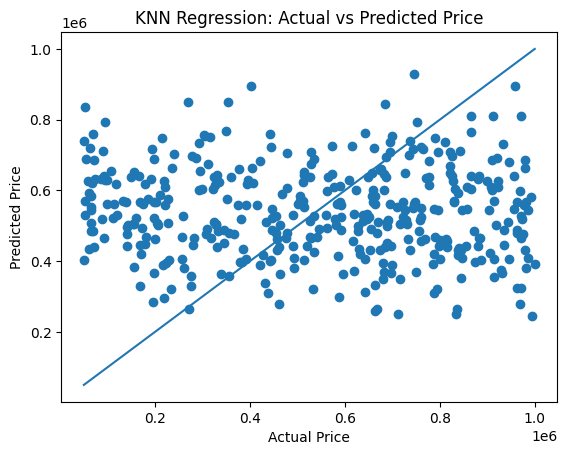

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("KNN Regression: Actual vs Predicted Price")

plt.show()